In [2]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum

import prior_configurations as prior_config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [3]:
save_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations'

config_list = [
    # ('cuesomaampa_Esomaampa_Edendnmda', prior_config.update_prior_dict_cuesomaampa_Esomaampa_Edendnmda), # 0
    # ('cuesomaampa_Esomanmda_Edendampa', prior_config.update_prior_dict_cuesomaampa_Esomanmda_Edendampa), # 1
    # ('cuesomanmda_Esomaampa_Edendnmda', prior_config.update_prior_dict_cuesomanmda_Esomaampa_Edendnmda), # 2
    # ('cuesomanmda_Esomanmda_Edendampa', prior_config.update_prior_dict_cuesomanmda_Esomanmda_Edendampa), # 3
    ('cuesomanmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomanmda_Esomaampa_Edendampa), # 4
    ('cuesomaampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuesomaampa_Esomaampa_Edendampa), # 5
    # ('cuedendampa_Esomaampa_Edendnmda', prior_config.update_prior_dict_cuedendampa_Esomaampa_Edendnmda), # 6
    # ('cuedendampa_Esomanmda_Edendampa', prior_config.update_prior_dict_cuedendampa_Esomanmda_Edendampa), # 7
    # ('cuedendnmda_Esomaampa_Edendnmda', prior_config.update_prior_dict_cuedendnmda_Esomaampa_Edendnmda), # 8
    # ('cuedendnmda_Esomanmda_Edendampa', prior_config.update_prior_dict_cuedendnmda_Esomanmda_Edendampa), # 9
    ('cuedendnmda_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendnmda_Esomaampa_Edendampa), # 10
    ('cuedendampa_Esomaampa_Edendampa', prior_config.update_prior_dict_cuedendampa_Esomaampa_Edendampa), # 11
    ]


t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [4]:
def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 10

    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error)


    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort}

    return res_dict

In [5]:
res_dict = dict()
for name, _ in config_list:
    data_path = f'{save_path}/{name}'
    res_dict[name] = get_opt_data(data_path)

Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuesomanmda_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuesomaampa_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuedendnmda_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9
Loading data from: /users/ntolley/data/ntolley/dendractor/memory_permutations/cuedendampa_Esomaampa_Edendampa
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Flow 5
Flow 6
Flow 7
Flow 8
Flow 9


In [ ]:
res_dict.keys()

In [7]:
# color_dict = {
#         'Edend_Isoma': 'C0', 'Edend_Idend': 'slateblue', 'Edend_Isomadend': 'lightsteelblue',
#         'Esoma_Isoma': 'C3', 'Esoma_Idend': 'darkorange', 'Esoma_Isomadend': 'rosybrown',
#         'Esomadend_Isoma': 'C2', 'Esomadend_Idend': 'palegreen', 'Esomadend_Isomadend': 'darkseagreen'}

color_dict = {
        'cuedendnmda_Esomaampa_Edendampa': 'C0',
        'cuedendampa_Esomaampa_Edendampa': 'lightsteelblue',
        'cuesomanmda_Esomaampa_Edendampa': 'C3',
        'cuesomaampa_Esomaampa_Edendampa': 'darkorange'
}

legend_dict = {
        'cuedendnmda_Esomaampa_Edendampa': '$\\rm NMDA_{dend}$',
        'cuedendampa_Esomaampa_Edendampa': '$\\rm AMPA_{dend}$',
        'cuesomanmda_Esomaampa_Edendampa': '$\\rm NMDA_{soma}$',
        'cuesomaampa_Esomaampa_Edendampa': '$\\rm AMPA_{soma}$'
}

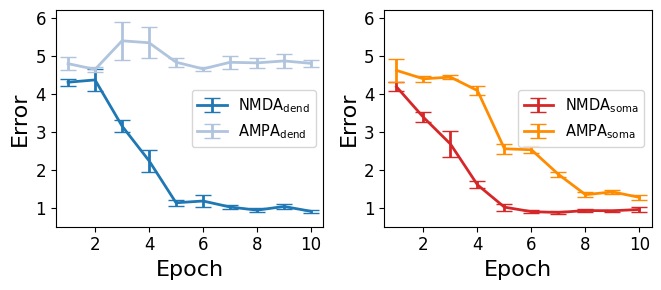

In [9]:
plot_groups = [
        ['cuedendnmda_Esomaampa_Edendampa', 'cuedendampa_Esomaampa_Edendampa'],
        ['cuesomanmda_Esomaampa_Edendampa', 'cuesomaampa_Esomaampa_Edendampa']]

labelsize = 16
ticksize = 12
legendsize = 10.5
linewidth = 2
xticks = np.array(list(range(1,len(res_dict['cuedendnmda_Esomaampa_Edendampa']['error_list'])+1)))

plt.figure(figsize=(10,3))
for plot_idx, group in enumerate(plot_groups):
    plt.subplot(1,3,plot_idx+1)
    for name in group:
        label = legend_dict[name]
        color = color_dict[name]
        error_avg = np.mean(np.array(res_dict[name]['error_list']), axis=1)
        # error_avg = np.min(np.array(res_dict[name]['error_list']), axis=1)
        error_std = np.std(np.array(res_dict[name]['error_list']), axis=1) / np.sqrt(100)
        plt.errorbar(x=xticks, y=error_avg, yerr=error_std, linewidth=linewidth, label=label, capsize=6, color=color)


    plt.xticks(fontsize=ticksize)
    plt.yticks(fontsize=ticksize)
    plt.legend(fontsize=legendsize, loc='center right')
    plt.ylabel('Error', fontsize=labelsize)
    plt.xlabel('Epoch', fontsize=labelsize)
    plt.ylim(0.5, 6.2)
    # plt.xlim(0, 11)
plt.tight_layout()

figure_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations/figures'
plt.savefig(f'{figure_path}/dendsoma_nmda_error_comparison.svg')